# Part 4 Task
## Graph Recreation

This notebook contains mostly explanations and useful examples for the modules `time`, `datetime` and `dateutil`.
There are a few exercises for you to make sure that you understand the concepts.

**Table of Content**
1. [Preparing the data](#sec1)
2. [Graph 1: total pageviews per show](#sec2)
3. [Graph 2: aligned pageview trajectories per show](#sec3)

<h1 id="sec1">Preparing the data</h1>

<h3>Import requirements</h3>

In [1]:
import mwclient
from mwclient import Site
from mwviews.api import PageviewsClient
from time import mktime
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time

<h3>Collect the pageview data from the selected shows</h3>

In [2]:
show_names = [
    "The Glory (TV series)", "Moving (South Korean TV series)", "My Demon", 
    "King the Land", "Gyeongseong Creature", "Twinkling Watermelon",
    "Death's Game", "Crash Course in Romance", "Welcome to Samdal-ri",
    "Celebrity (South Korean TV series)", "A Time Called You", "Perfect Marriage Revenge",
    "See You in My 19th Life", "The Good Bad Mother", "My Lovely Liar",
    "Doona!", "Love to Hate You (TV series)", "Daily Dose of Sunshine",
    "Destined with You"
]

In [3]:
p = PageviewsClient(user_agent="CS 315 student (nh107)")
data = p.article_views('en.wikipedia', show_names, 
                       start='20220601', end='20240601')

In [30]:
pageviews_df = pd.DataFrame(data)

pageviews_df

,2022-06-01,2022-06-02,2022-06-03,2022-06-04,2022-06-05,2022-06-06,2022-06-07,2022-06-08,2022-06-09,2022-06-10,...,2024-05-23,2024-05-24,2024-05-25,2024-05-26,2024-05-27,2024-05-28,2024-05-29,2024-05-30,2024-05-31,2024-06-01
The_Glory_(TV_series),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2493,2680,2699,2951,2878,2761,2638,2500,2608,2614
Moving_(South_Korean_TV_series),199.0,176.0,183.0,167.0,212.0,166.0,187.0,205.0,197.0,159.0,...,1424,1314,1441,1858,1643,1756,1551,1656,1866,1778
My_Demon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1632,1615,1631,1782,1676,1620,1566,1480,1572,1715
King_the_Land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,995,1004,1026,1250,1255,1195,1129,1182,1064,1049
Gyeongseong_Creature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1184,1219,1338,1408,1304,1261,1210,1369,1363,1399
Twinkling_Watermelon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1671,1721,1763,1879,1930,2032,2205,2169,2114,2013
Death's_Game,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1335,1533,1623,1669,1476,1410,1290,1365,1406,1411
Crash_Course_in_Romance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,582,567,640,696,738,715,638,639,642,586
Welcome_to_Samdal-ri,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,892,963,1028,1041,1080,1068,961,982,1044,1074
Celebrity_(South_Korean_TV_series),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,748,739,768,792,713,732,757,691,666,702


<h1 id="sec2">Graph 1: total pageviews per show</h1>

<p>This graph is a horizontal bar chart of aggregate pageviews from 2022-06-01 to 2024-06-01 for each show.</p>

<h3>Get aggregate pageviews for each show</h3>

In [31]:
pageviews_df["pageviews_sum"] = pageviews_df.sum(axis=1)

pageviews_sum_df = pageviews_df[["pageviews_sum"]].reset_index()
pageviews_sum_df = pageviews_sum_df.sort_values("pageviews_sum")

In [32]:
pageviews_sum_df

,index,pageviews_sum
18,Destined_with_You,1156.0
17,Daily_Dose_of_Sunshine,559765.0
16,Love_to_Hate_You_(TV_series),822729.0
15,Doona!,1033094.0
14,My_Lovely_Liar,1169482.0
13,The_Good_Bad_Mother,1172570.0
12,See_You_in_My_19th_Life,1247697.0
11,Perfect_Marriage_Revenge,1266164.0
10,A_Time_Called_You,1349860.0
9,Celebrity_(South_Korean_TV_series),1441608.0


<h3>Plot graph</h3>

(0.0, 5980838.600000001)

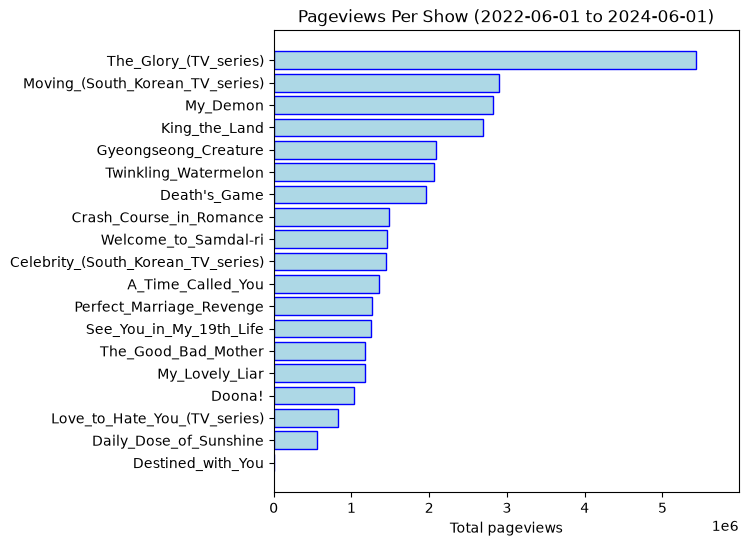

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

#create  a horizontal bar graph
ax.barh(
    pageviews_sum_df['index'], 
    width=pageviews_sum_df['pageviews_sum'],
    color="lightblue",
    edgecolor="blue",
    )
ax.set_title('Pageviews Per Show (2022-06-01 to 2024-06-01)')
ax.set_xlabel("Total pageviews")
ax.yaxis.tick_left()

#get the highest value for pageviews_sum for the x axis scaling (idk if this is necessary)
max_pageviews = pageviews_sum_df["pageviews_sum"].max()
#leave space at the end 
plt.xlim(0, max_pageviews * 1.10)

<h1 id="sec3">Graph 2: aligned pageview trajectories per show</h1>

<p>describe</p>

<h3>do stuff

In [34]:
pageviews_df = pageviews_df.drop(columns=["pageviews_sum"])

In [35]:
pageviews_df["pageviews_max"] = pageviews_df.idxmax(axis=1)

pageviews_max_df = pageviews_df[["pageviews_max"]].reset_index()
pageviews_max_df = pageviews_max_df.sort_values("pageviews_max")

In [45]:
pageviews_max_df

,index,pageviews_max
18,Destined_with_You,2023-01-17
16,Love_to_Hate_You_(TV_series),2023-02-11
7,Crash_Course_in_Romance,2023-03-05
0,The_Glory_(TV_series),2023-03-12
13,The_Good_Bad_Mother,2023-06-09
12,See_You_in_My_19th_Life,2023-06-18
3,King_the_Land,2023-06-18
9,Celebrity_(South_Korean_TV_series),2023-07-02
14,My_Lovely_Liar,2023-08-09
1,Moving_(South_Korean_TV_series),2023-08-17


In [36]:
pageviews_max_df

,index,pageviews_max
18,Destined_with_You,2023-01-17
16,Love_to_Hate_You_(TV_series),2023-02-11
7,Crash_Course_in_Romance,2023-03-05
0,The_Glory_(TV_series),2023-03-12
13,The_Good_Bad_Mother,2023-06-09
12,See_You_in_My_19th_Life,2023-06-18
3,King_the_Land,2023-06-18
9,Celebrity_(South_Korean_TV_series),2023-07-02
14,My_Lovely_Liar,2023-08-09
1,Moving_(South_Korean_TV_series),2023-08-17


In [93]:
show_names = list(pageviews_max_df["index"])

data = []
for show in show_names:
    max_date = pageviews_max_df[pageviews_max_df["index"] == show].iloc[0, 1]
    max_date = pd.to_datetime(max_date)

    #get the 100 day window with max_date in the middle (gemini assisted me here)
    start_date = max_date - pd.Timedelta(days=50)
    end_date = max_date + pd.Timedelta(days=50)

    #get the slice of the dataframe for this window of time
    temp_df = pageviews_df.loc[show, start_date:end_date]

    #transform the temp df into a dict
    # this lets us save all values together even when the columns have diff dates
    values = temp_df.values
    row_dict = {i: val for i, val in enumerate(values)}
    row_dict["show"] = show
    
    data.append(row_dict)

data = pd.DataFrame(data).set_index("show")
data = data.sort_values(50, ascending=False)
print(data.head(1))

                           0        1        2        3        4        5    \
show                                                                          
The_Glory_(TV_series)  23957.0  23915.0  23048.0  19753.0  19383.0  17754.0   

                           6        7        8        9    ...      91   \
show                                                       ...            
The_Glory_(TV_series)  16622.0  18076.0  18858.0  17479.0  ...  13370.0   

                           92       93       94       95       96       97   \
show                                                                          
The_Glory_(TV_series)  14098.0  12785.0  12839.0  12023.0  12119.0  16502.0   

                           98       99       100  
show                                              
The_Glory_(TV_series)  19760.0  18443.0  17280.0  

[1 rows x 101 columns]


<h3>Plot graph</h3>

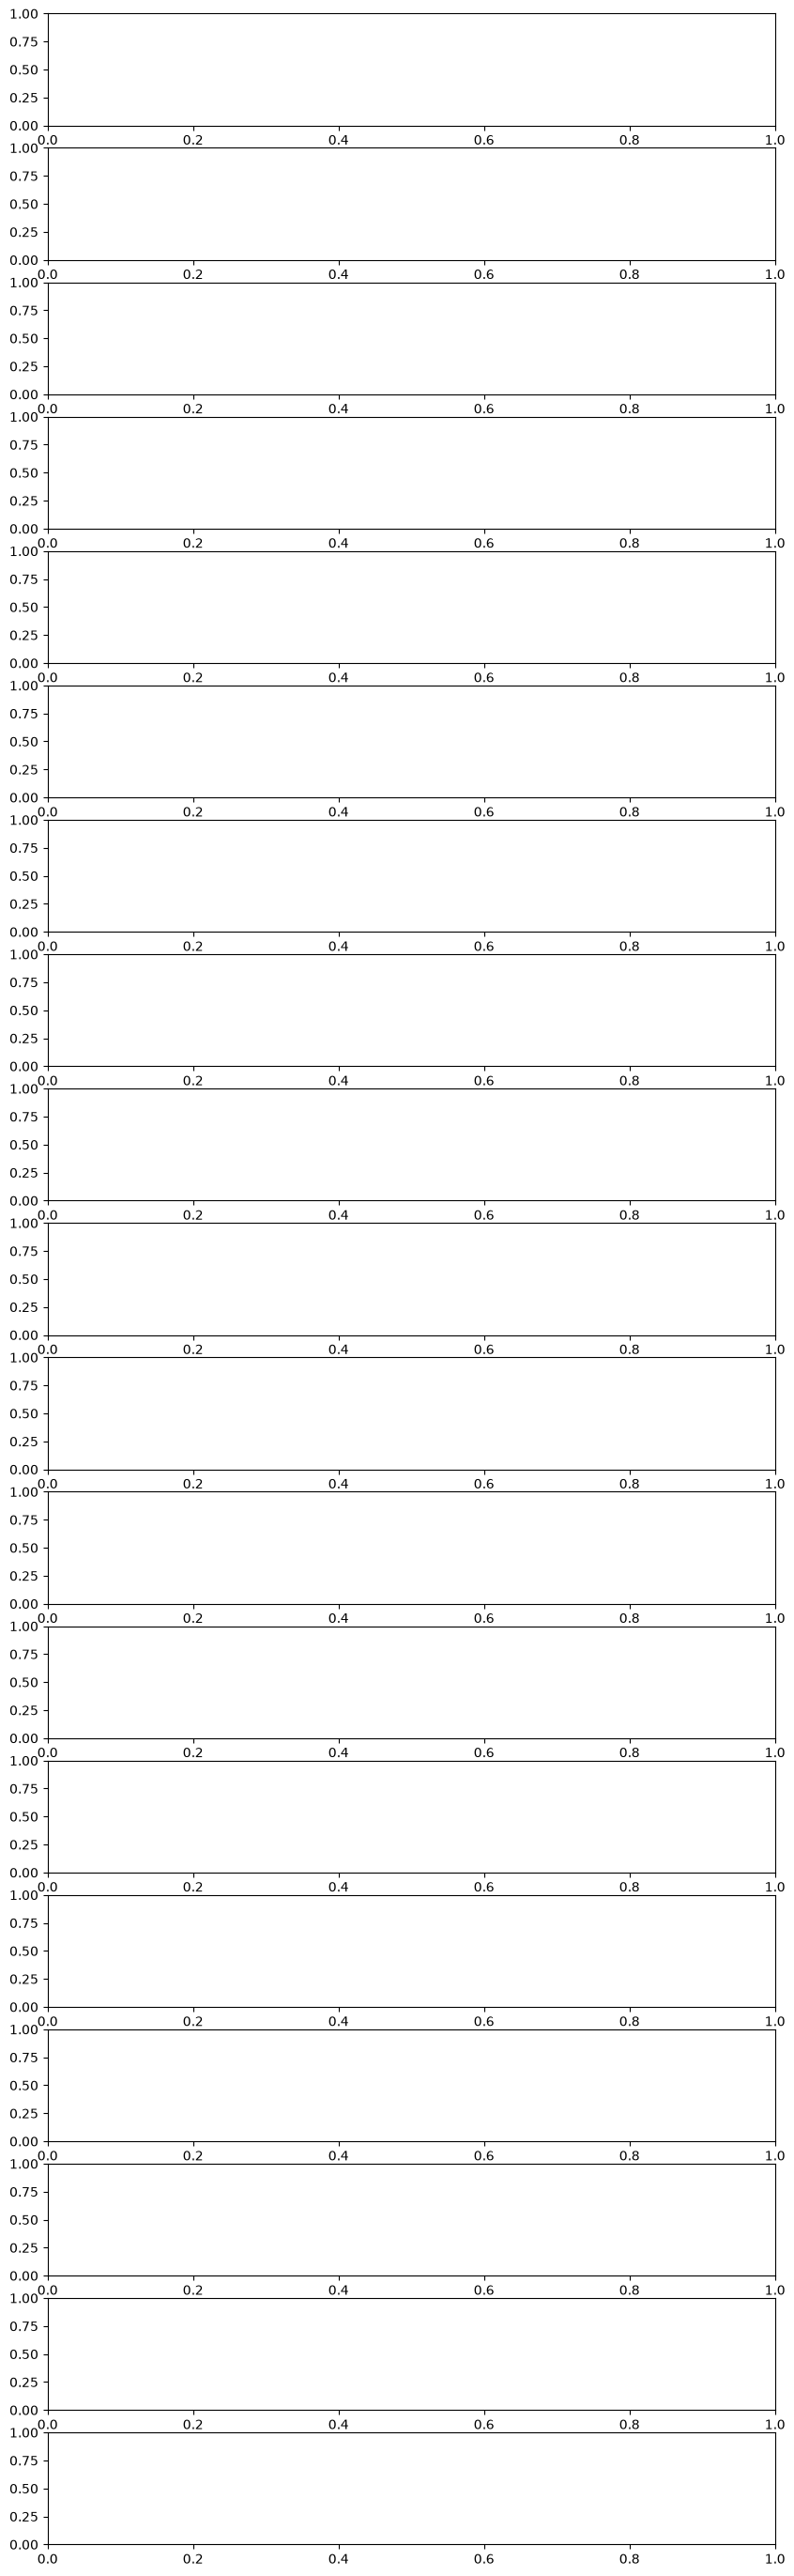

In [90]:
fig, ax = plt.subplots(nrows=19, ncols=1, figsize=(10, 35))